In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest

In [16]:
results = pd.read_csv(
    r"C:\Users\Avilasha\Desktop\CPU_Predictive_Maintenance\CPU\data\Processed\forecast_results_1.csv"   # for total server data: use cpu_features.csv
)

print(results.shape)
results.head()

results['Timestamp'] = pd.to_datetime(
    results['Timestamp'],
    format='mixed',
    utc=True
)

results = results.sort_values(
    'Timestamp'
).reset_index(drop=True)

print(results.dtypes)

(4917, 11)
host_id                                int64
hostName                              object
Timestamp                datetime64[ns, UTC]
cpu_usage_pct                        float64
Actual_1hr                           float64
Predicted_1hr                        float64
memory_usage_pct                     float64
power_kw                             float64
cpu_temp_c                             int64
inlet_temp_c                           int64
resource_stress_index                float64
dtype: object


In [17]:
# Forecast error
results['forecast_error'] = (
    results['Actual_1hr'] - results['Predicted_1hr']
).abs()
results.head()


,host_id,hostName,Timestamp,cpu_usage_pct,Actual_1hr,Predicted_1hr,memory_usage_pct,power_kw,cpu_temp_c,inlet_temp_c,resource_stress_index,forecast_error
0,1,10.10.10.65,2026-05-25 01:49:17.719000+00:00,1.0,1.0,1.474220,28.0,0.219,40,25,15.5,0.474220
1,1,10.10.10.65,2026-05-25 01:54:19.936000+00:00,1.0,1.0,1.967517,28.0,0.220,42,28,14.5,0.967517
2,1,10.10.10.65,2026-05-25 01:59:16.907000+00:00,1.0,1.0,1.909188,28.0,0.220,42,25,15.5,0.909188
3,1,10.10.10.65,2026-05-25 02:04:19.360000+00:00,1.0,1.0,1.257034,28.0,0.220,39,21,14.5,0.257034
4,1,10.10.10.65,2026-05-25 02:09:18.002000+00:00,1.0,1.0,1.832747,28.0,0.220,40,25,14.5,0.832747


In [18]:
df = pd.read_csv(
    r"C:\Users\Avilasha\Desktop\CPU_Predictive_Maintenance\CPU\data\Processed\forecast_results_3.csv"
)
print(df.shape)
df['ts'] = pd.to_datetime(
    df['Timestamp'],
    format='mixed',
    utc=True
)
df = df.sort_values(
    ['host_id','ts']
)

(4917, 11)


In [19]:
SERVER_ID = 3
df = df[
    df['host_id'] == SERVER_ID
].copy()
SERVER_NAME = df['hostName'].iloc[0]
print("Server:", SERVER_NAME)
print(df.shape)

Server: 10.10.10.2
(4917, 12)


In [20]:
# Features for isolation forest
# iso_features = [
#     'cpu_usage_pct',
#     'memory_usage_pct',
#     'power_kw',
#     'cpu_temp_c',
#     'resource_stress_index'
# ]
# X_iso = df[
#     iso_features
# ]
# print(X_iso.shape)

# Features for FUTURE anomaly detection

iso_features = [
    'Actual_1hr',
]

X_iso = df[
    iso_features
]

print(X_iso.shape)

(4917, 1)


In [21]:
# Train isolation forest
iso_model = IsolationForest(
    n_estimators=300,
    contamination=0.001,
    random_state=42
)
iso_model.fit(
    X_iso
)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",300
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.001
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [22]:
# Predict anomalies
df['iso_label'] = (
    iso_model.predict(X_iso)
)
# iso_model.predict(X_iso) returns:
# 1 → normal (inlier)
# -1 → anomaly (outlier)
df['iso_anomaly'] = (
    df['iso_label'] == -1
)   # creates true/false column: True(anomaly -1)/False(normal 1)
print(
    "Total anomalies:",
    df['iso_anomaly'].sum()
)
print(
    df['iso_anomaly']
    .value_counts()
)

Total anomalies: 5
iso_anomaly
False    4912
True        5
Name: count, dtype: int64


In [23]:
# Exact timestamp table
# anomaly_table = df[
#     df['iso_anomaly']
# ].copy()
# anomaly_table = anomaly_table[
#     [
#         'ts',
#         'host_id',
#         'hostName',
#         'cpu_usage_pct',
#         'memory_usage_pct',
#         'power_kw',
#         'cpu_temp_c',
#         'resource_stress_index'
#     ]
# ]
# anomaly_table = anomaly_table.sort_values(
#     'ts'
# )
# anomaly_table.head(50)

# Future anomaly table

anomaly_table = df[
    df['iso_anomaly']
].copy()

anomaly_table = anomaly_table[
    [
        'host_id',
        'hostName',
        'ts',
        'Actual_1hr',
        'Predicted_1hr',
    ]
]
anomaly_table = anomaly_table.sort_values(
    'ts'
)
display(
    anomaly_table.head(100)
)

,host_id,hostName,ts,Actual_1hr,Predicted_1hr
1405,3,10.10.10.2,2026-05-29 22:59:18.624000+00:00,36.00,28.345755
3410,3,10.10.10.2,2026-06-05 22:01:14.436000+00:00,35.04,30.765562
3438,3,10.10.10.2,2026-06-06 00:21:11.894000+00:00,35.09,30.818802
3617,3,10.10.10.2,2026-06-06 15:16:14.139000+00:00,35.69,29.916110
4663,3,10.10.10.2,2026-06-10 06:30:05.714000+00:00,36.42,28.279951


In [24]:
import sys
!{sys.executable} -m pip install plotly


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
# # Interacive anomaly plot
# import plotly.graph_objects as go
# import plotly.io as pio
# pio.renderers.default = "browser"

# anomalies = df[
#     df['iso_anomaly']
# ].copy()
# fig = go.Figure()
# # CPU Line
# fig.add_trace(
#     go.Scatter(
#         x=df['ts'],
#         y=df['cpu_usage_pct'],
#         mode='lines',
#         name='CPU Usage',
#         line=dict(
#             width=1
#         )
#     )
# )
# # Anomaly Markers
# fig.add_trace(
#     go.Scatter(
#         x=anomalies['ts'],
#         y=anomalies['cpu_usage_pct'],
#         mode='markers+text',
#         name='Isolation Forest Anomaly',
#         marker=dict(
#             color='red',
#             size=12,
#             line=dict(
#                 color='black',
#                 width=1
#             )
#         ),
#         text=[
#             ts.strftime(
#                 "%d-%m-%Y %H:%M"
#             )
#             for ts in anomalies['ts']
#         ],
#         textposition="top center",
#         hovertemplate=
#         "<b>Timestamp:</b> %{text}<br>" +
#         "<b>CPU:</b> %{y:.2f}%<br>" +
#         "<extra></extra>"
#     )
# )
# fig.update_layout(
#     title=
#     f"{SERVER_NAME} | Isolation Forest CPU Anomalies",
#     xaxis_title="Timestamp",
#     yaxis_title="CPU Usage (%)",
#     hovermode='closest',
#     height=800
# )
# fig.show()


# =====================================
# INTERACTIVE FUTURE ANOMALY PLOT
# =====================================

import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "browser"

anomalies = df[
    df['iso_anomaly']
].copy()

fig = go.Figure()

# Predicted CPU Line
fig.add_trace(
    go.Scatter(
        x=df['ts'],
        y=df['Actual_1hr'],
        mode='lines',
        name='Predicted CPU',
        line=dict(width=1)
    )
)

# Future anomaly markers
fig.add_trace(
    go.Scatter(
        x=anomalies['ts'],
        y=anomalies['Actual_1hr'],
        mode='markers+text',
        name='Future Anomaly',

        marker=dict(
            color='red',
            size=12,
            line=dict(
                color='black',
                width=1
            )
        ),

        text=[
            ts.strftime("%d-%m-%Y %H:%M")
            for ts in anomalies['ts']
        ],

        textposition="top center",

        hovertemplate=
        "<b>Timestamp:</b> %{text}<br>" +
        "<b>Predicted CPU:</b> %{y:.2f}%<br>" +
        "<extra></extra>"
    )
)

fig.update_layout(

    title=
    f"{SERVER_NAME} | CPU Anomalies",

    xaxis_title="Timestamp",

    yaxis_title="Actual CPU Usage (%)",

    hovermode='closest',

    height=850
)

fig.show()

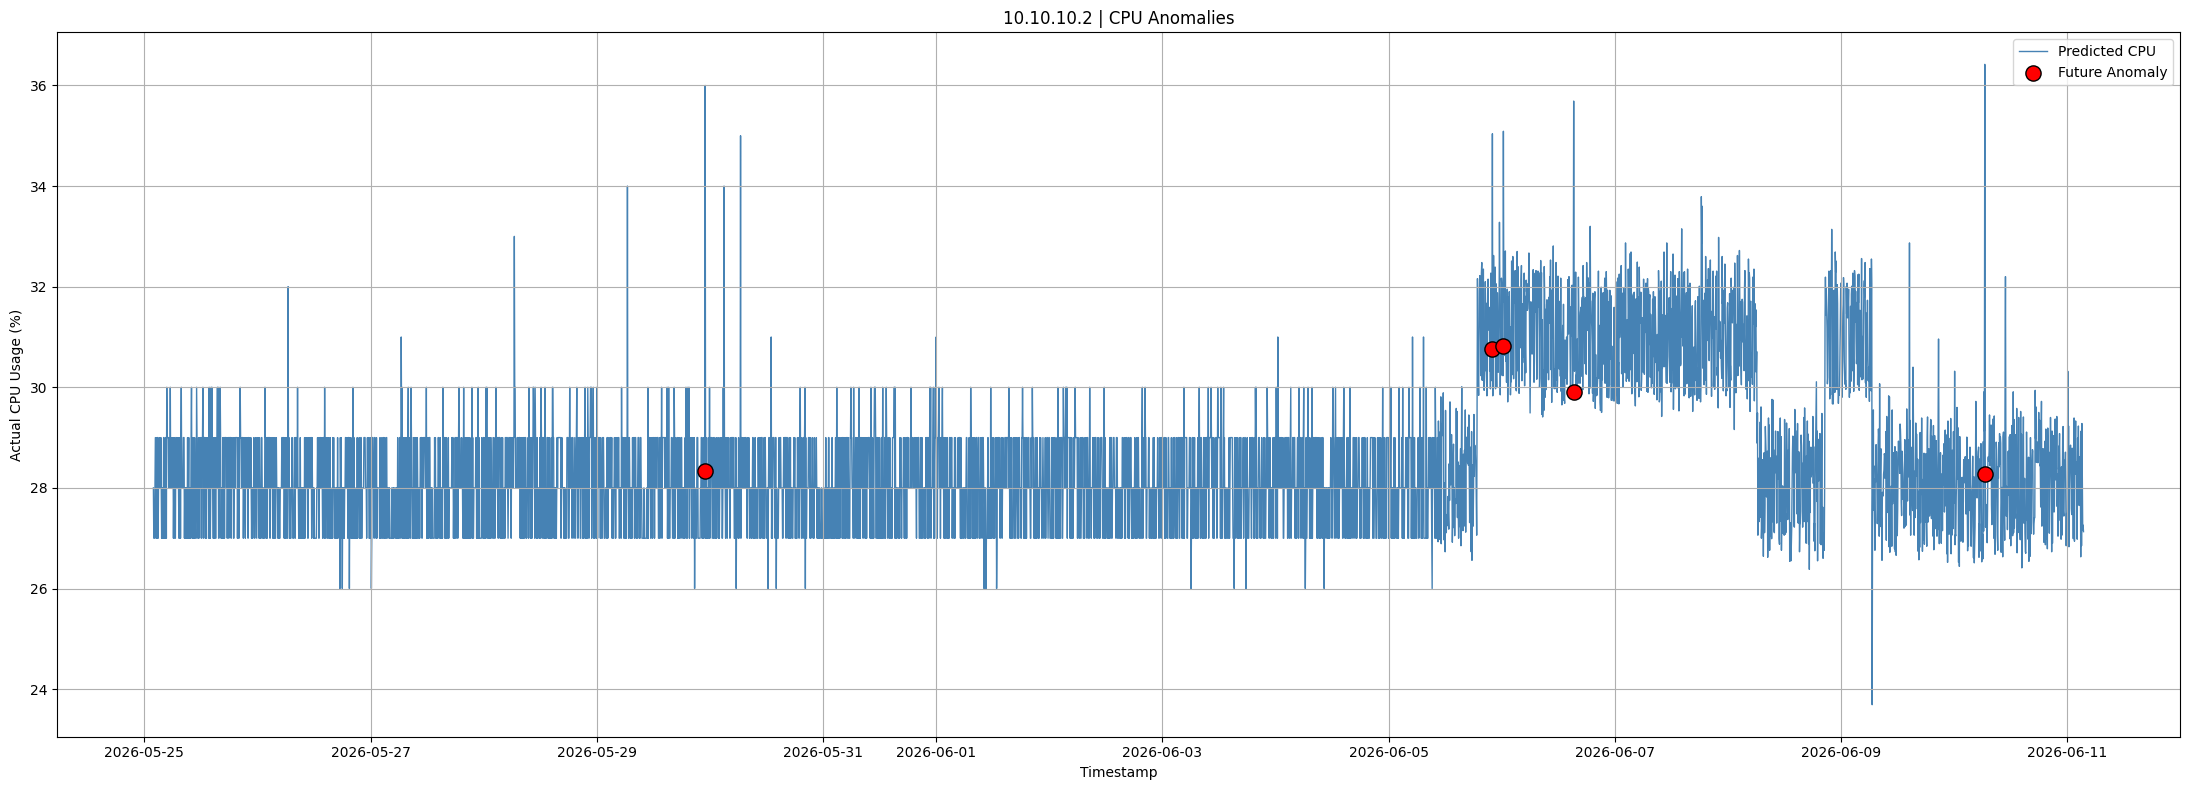

In [26]:
# import matplotlib.pyplot as plt
# import matplotlib.dates as mdates
# plt.figure(figsize=(22,8))
# plt.plot(
#     df['ts'],
#     df['cpu_usage_pct'],
#     color='steelblue',
#     linewidth=1,
#     label='CPU Usage',
#     zorder=1
# )
# plt.scatter(
#     df.loc[df['iso_anomaly'], 'ts'],
#     df.loc[df['iso_anomaly'], 'cpu_usage_pct'],
#     color='red',
#     marker='o',
#     s=120,
#     edgecolors='black',
#     linewidths=1,
#     zorder=20,
#     label='Anomaly'
# )
# plt.title(
#     f'{SERVER_NAME} | Isolation Forest CPU Anomalies'
# )
# plt.xlabel('Timestamp')
# plt.ylabel('CPU Usage (%)')
# # More frequent timestamps
# ax = plt.gca()
# ax.xaxis.set_major_locator(
#     mdates.DayLocator(interval=1)
# )
# ax.xaxis.set_major_formatter(
#     mdates.DateFormatter('%d-%m\n%H:%M')
# )
# plt.xticks(rotation=45)
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.show()

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(22,8))

plt.plot(
    df['ts'],
    df['Actual_1hr'],
    color='steelblue',
    linewidth=1,
    label='Predicted CPU',
    zorder=1
)

plt.scatter(
    df.loc[df['iso_anomaly'], 'ts'],
    df.loc[df['iso_anomaly'], 'Predicted_1hr'],
    color='red',
    marker='o',
    s=120,
    edgecolors='black',
    linewidths=1,
    zorder=20,
    label='Future Anomaly'
)

plt.title(
    f'{SERVER_NAME} | CPU Anomalies'
)

plt.xlabel('Timestamp')
plt.ylabel('Actual CPU Usage (%)')

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

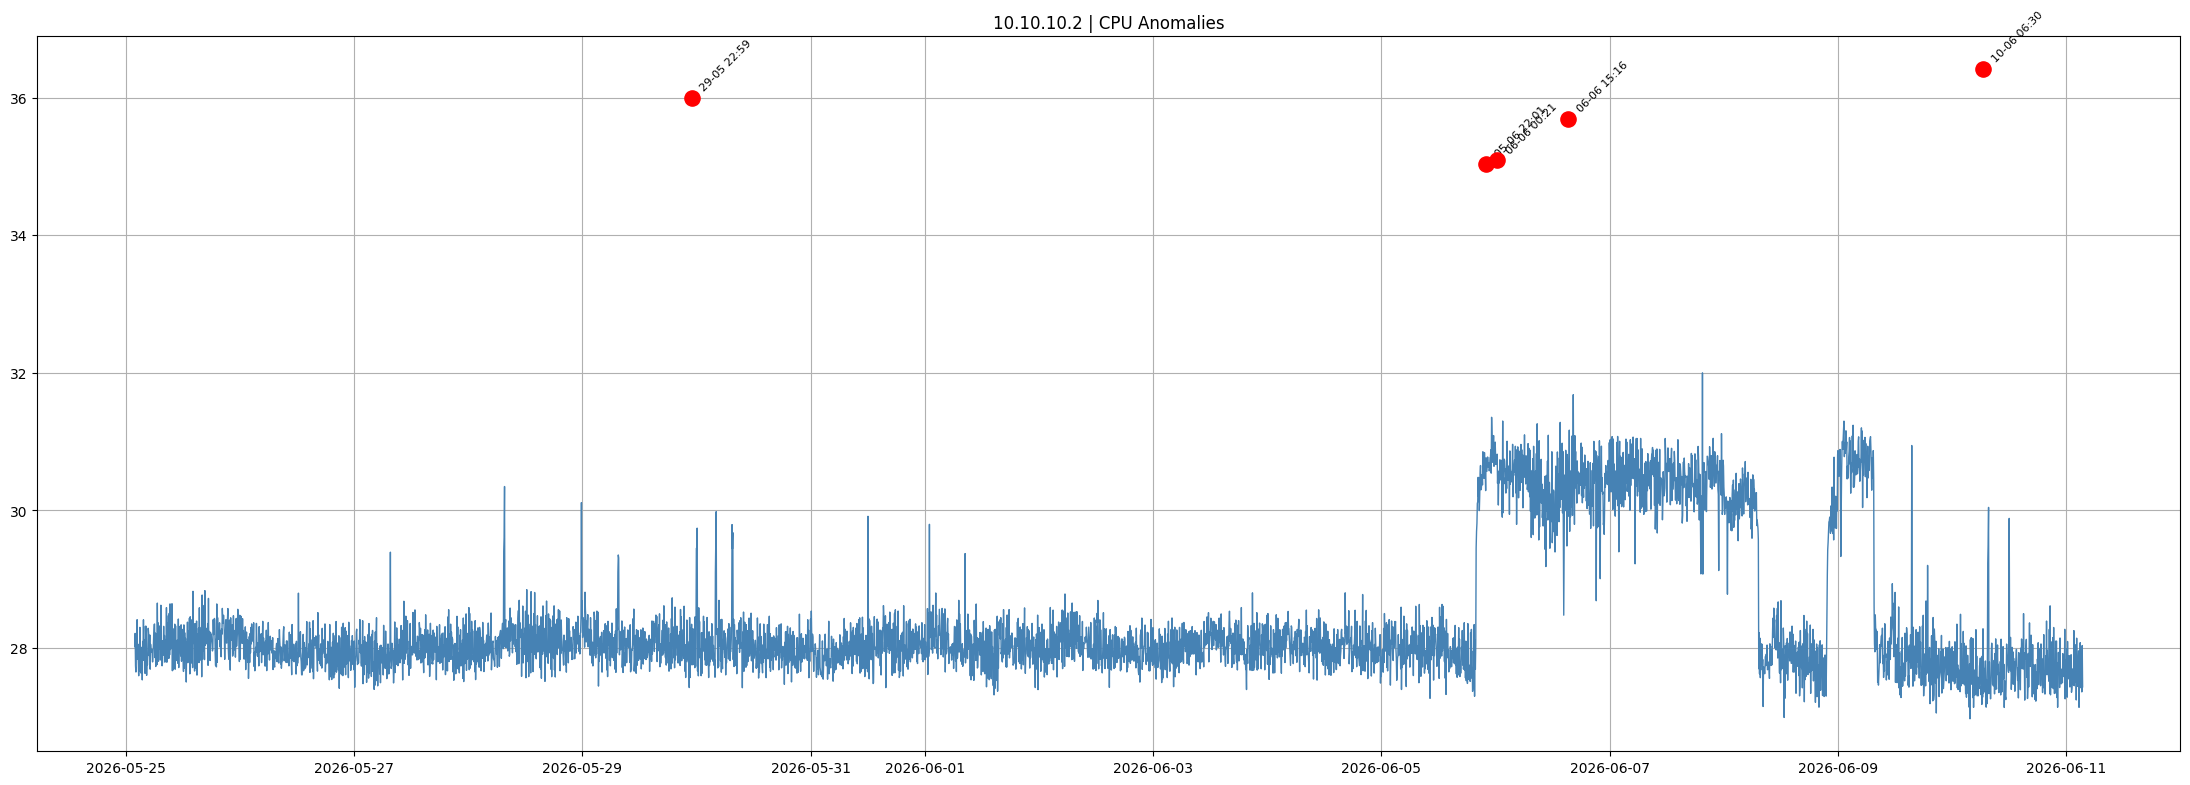

In [27]:
# import matplotlib.pyplot as plt
# import matplotlib.dates as mdates

# plt.figure(figsize=(22,8))

# plt.plot(
#     df['ts'],
#     df['cpu_usage_pct'],
#     color='steelblue',
#     linewidth=1
# )

# anomalies = df[
#     df['iso_anomaly']
# ]

# plt.scatter(
#     anomalies['ts'],
#     anomalies['cpu_usage_pct'],
#     color='red',
#     s=120,
#     zorder=20
# )

# for _, row in anomalies.iterrows():

#     plt.annotate(
#         row['ts'].strftime('%d-%m %H:%M'),
#         (
#             row['ts'],
#             row['cpu_usage_pct']
#         ),
#         fontsize=8,
#         rotation=45,
#         xytext=(5,5),
#         textcoords='offset points'
#     )

# plt.title(
#     f'{SERVER_NAME} | Isolation Forest CPU Anomalies'
# )

# plt.grid(True)

# plt.tight_layout()

# plt.show()

import matplotlib.pyplot as plt
plt.figure(figsize=(22,8))
plt.plot(
    df['ts'],
    df['Predicted_1hr'],
    color='steelblue',
    linewidth=1
)
anomalies = df[
    df['iso_anomaly']
]

plt.scatter(
    anomalies['ts'],
    anomalies['Actual_1hr'],
    color='red',
    s=120,
    zorder=20
)

for _, row in anomalies.iterrows():

    plt.annotate(
        row['ts'].strftime('%d-%m %H:%M'),
        (
            row['ts'],
            row['Actual_1hr']
        ),
        fontsize=8,
        rotation=45,
        xytext=(5,5),
        textcoords='offset points'
    )

plt.title(
    f'{SERVER_NAME} | CPU Anomalies'
)

plt.grid(True)

plt.tight_layout()

plt.show()

In [28]:
# Table of detected anomalies
# =====================================================
# ANOMALY TABLE
# =====================================================

# =====================================================
# FUTURE ANOMALY TABLE
# =====================================================

anomaly_table = df[
    df['iso_anomaly']
].copy()

anomaly_table = anomaly_table[
    [
        'host_id',
        'hostName',
        'ts',
        'Actual_1hr'
    ]
]

display(anomaly_table)

,host_id,hostName,ts,Actual_1hr
1405,3,10.10.10.2,2026-05-29 22:59:18.624000+00:00,36.00
3410,3,10.10.10.2,2026-06-05 22:01:14.436000+00:00,35.04
3438,3,10.10.10.2,2026-06-06 00:21:11.894000+00:00,35.09
3617,3,10.10.10.2,2026-06-06 15:16:14.139000+00:00,35.69
4663,3,10.10.10.2,2026-06-10 06:30:05.714000+00:00,36.42
